# Работа с обученной моделью

In [1]:
import joblib
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

## Загрузка модели и данных

In [2]:
model = joblib.load('best_mlp.pkl')
X_test, y_test = joblib.load('test_data.pkl')

print("Параметры модели:")
mlp = model
params = mlp.get_params()
for param, value in params.items():
    print(f"{param}: {value}")

print(f"\nКоличество итераций: {mlp.n_iter_}")
print(f"Финальный loss: {mlp.loss_}")

Параметры модели:
activation: relu
alpha: 0.0001
batch_size: auto
beta_1: 0.9
beta_2: 0.999
early_stopping: False
epsilon: 1e-08
hidden_layer_sizes: (30, 10)
learning_rate: constant
learning_rate_init: 0.001
max_fun: 15000
max_iter: 500
momentum: 0.9
n_iter_no_change: 10
nesterovs_momentum: True
power_t: 0.5
random_state: 42
shuffle: True
solver: adam
tol: 0.0001
validation_fraction: 0.1
verbose: True
warm_start: False

Количество итераций: 180
Финальный loss: 0.27520320839191875


/home/pavel/myenv/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LabelBinarizer from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/pavel/myenv/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator MLPClassifier from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


## Оценка качества

Accuracy: 0.8768101162553539

Classification report:
              precision    recall  f1-score   support

         0.0       0.88      0.87      0.88     22064
         1.0       0.87      0.88      0.88     22063

    accuracy                           0.88     44127
   macro avg       0.88      0.88      0.88     44127
weighted avg       0.88      0.88      0.88     44127



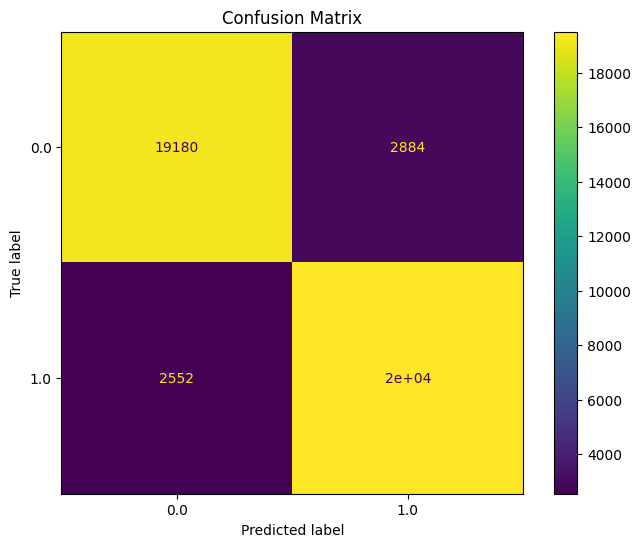

In [3]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification report:")
print(classification_report(y_test, y_pred))

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax)
plt.title('Confusion Matrix')
plt.show()

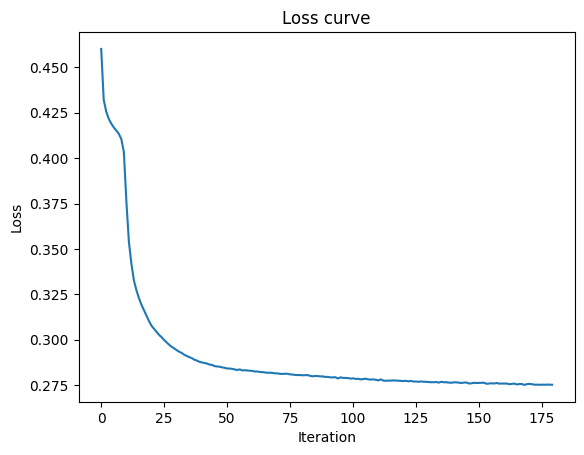

In [4]:
plt.plot(mlp.loss_curve_)
plt.title('Loss curve')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.show()